In [190]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import pandas as pd
from IPython.display import display
import openpyxl

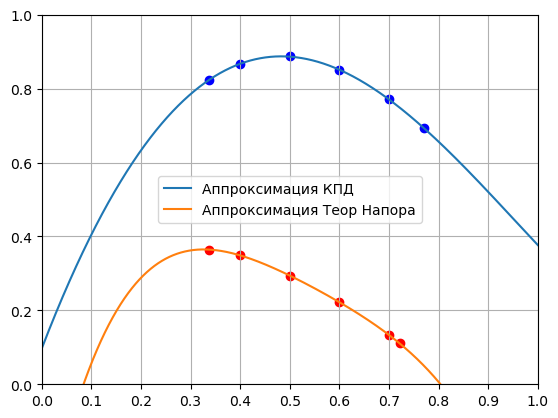

In [191]:
# График с учебника рис. 4

# Точки
x_η_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])       # точки по оси X для теоретического напора
η_dots = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])      # точки по оси Y для теоретического напора

x_Hт_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])    # точки по оси X для КПД
Hт_dots = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721]) # точки по оси Y для КПД

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(x_Hт_dots, Hт_dots, stepen)
poly = np.poly1d(coeffs)
coeffs1 = np.polyfit(x_η_dots, η_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000     # Число точек
x_Hт_dots_smooth = np.linspace(0, 1, smoothness)
Hт_dots_smooth = poly(x_Hт_dots_smooth)
x_η_dots_smooth = np.linspace(0, 1, smoothness)
η_dots_smooth = poly1(x_η_dots_smooth)

plt.plot(x_η_dots_smooth, η_dots_smooth, label="Аппроксимация КПД")
plt.plot(x_Hт_dots_smooth, Hт_dots_smooth, label="Аппроксимация Теор Напора")
plt.scatter(x_Hт_dots, Hт_dots, color="red")
plt.scatter(x_η_dots, η_dots, color="blue")
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.arange(0, 1.1, 0.1))  # Установка делений по оси X с шагом 0.1
plt.yticks(np.arange(0, 1.1, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()

Hт_x_line = x_Hт_dots_smooth    # Координаты X для линии теоретического напора
Hт_y_line = Hт_dots_smooth      # Координаты Y для линии теоретического напора
η_x_line = x_η_dots_smooth      # Координаты X для линии КПД
η_y_line = η_dots_smooth        # Координаты Y для линии КПД


In [192]:
Tа_полн = 288   # K
Pа_полн = 1.013 * 10**5  # Па
G_в = 58.7  # кг/с
π_к_полн = 18.2  # Степень повышения давления в компрессоре
n = 8600  # об/мин

R_в = 287.4  # Дж/(кг*К)
k = 1.4  # показатель адиабаты для воздуха
# Дж/(кг*К) удельная теплоемкость при постоянном давлении для воздуха
c_p = 1006

# 2. Выбор основных параметров компрессора и предварительный расчет проточной части по средней линии тока

## Предварительный расчет проточной части по средней линии тока

In [193]:
d1_отн = 0.4
c_а1_отн = 0.45
c_a2_отн = 0.3
Hт_ср_отн = 0.3
R_ср1 = 0.5
H_т1 = 0.2
D_type = 'D_к_const'

# Первое приближение

In [194]:
n = n / (60 / (2 * math.pi))  # Преобразуем обороты в радианы в секунду
print(f" n = {n}")

 n = 900.589894029074


In [195]:
def η_к_полн_def(π_к_полн, k, η_пол):
    η_к_полн = (((π_к_полн)**((k-1)/k)-1) / ((π_к_полн)**((k-1)/(k*η_пол))-1) - 0.02)
    return(η_к_полн)

def Tk_полн_def(π_к_полн, k, η_пол, Tа_полн):
    η_к_полн = η_к_полн_def(π_к_полн, k, η_пол)
    Tk_полн = Tа_полн * (1 + ((π_к_полн**((k-1)/k)-1) / η_к_полн))
    return(Tk_полн)

def a_кр_def(k, R_в, T):
    a_кр = math.sqrt((2*k/(k+1))*R_в*T)
    return(a_кр)

def ρ_полн_def(P_полн, T_полн, R_в):
    ρ_полн = P_полн / (T_полн * R_в)
    return(ρ_полн)

def U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн):
    U_k = math.cbrt((G_в * n**2)/(math.pi * c_а1_отн * ρ1_полн * (1 - d1_отн**2)))
    return(U_k)

def c_real_def(U_k1, c_а_отн):
    c_real = U_k1 * c_а_отн
    return(c_real)

def λ_def(c_real, a_кр):
    λ = c_real / a_кр
    return(λ)

def ε_gdf(k, λ):
    return (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def σ_in_gdf(ξ, k, ε, λ):
    return (1 / (1 + ξ * (k/(k+1)) * ε * λ**2))

def σ_out_gdf(ξ, k, ε, λ):
    return (1 - ξ * (k/(k+1)) * ε * λ**2)

def radius_отн(d_отн):
    return math.sqrt( (1 + d_отн**2) / 2)

def c_u_отн_def(r_ср_отн, R_ср, H_т):
    c_u_отн = r_ср_отн * (1 - R_ср) - (H_т / (2 * r_ср_отн))
    return(c_u_отн)

def q_gdf(k, λ):
    return ((k+1)/2)**(1/(k-1)) * λ * (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def F_tube(G_в, R_в, T, β, P, q):
    return (G_в * math.sqrt(R_в * T)) / (β * P * q)

In [196]:
# Определим адиабатический КПД
η_пол = 0.90 # Политропический КПД компрессора из рис.1

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

#  Ожидаемый КПД
η_к_полн = η_к_полн_def(π_к_полн, k, η_пол)

# Температура на выходе из ЛА компрессора
Tk_полн = Tk_полн_def(π_к_полн, k, η_пол, Tа_полн)
T2_полн = Tk_полн

# Критическая скорость звука во входном и выходном патрубках
a_кр_вх = a_кр_def(k, R_в, Tа_полн)
a_кр_вых = a_кр_def(k, R_в, Tk_полн)

# Плотность рабочего тела по заторможенным параметрам
ρ1_полн = ρ_полн_def(Pа_полн, Tа_полн, R_в)

# Окружная скорость реальная на конце лопатки
U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн)
print(U_k1)
print(G_в, n, c_а1_отн, ρ1_полн, d1_отн)
# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = c_real_def(U_k1, c_а1_отн)
c_вых = c_real_def(U_k1, c_a2_отн)

# Приведенные скорости в данных сечениях
λ_вх = λ_def(c_вх, a_кр_вх)
λ_вых = λ_def(c_вых, a_кр_вых)

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)


π_ла_полн = π_к_полн / (σ_вх * σ_вых)
η_ла_полн = ((π_ла_полн)**((k-1)/k)-1) / ((π_ла_полн)**((k-1)/(k*η_пол))-1)


print(f"""
σ_вх * σ_вых = {σ_вх * σ_вых}
π_ла_полн = {π_ла_полн}
η_к_полн = {η_к_полн}
η_ла_полн = {η_ла_полн}
""")

319.9681800746992
58.7 900.589894029074 0.45 1.223855640609294 0.4

σ_вх * σ_вых = 0.9911087573907559
π_ла_полн = 18.363272309200717
η_к_полн = 0.8338097173818555
η_ла_полн = 0.853654218772678



In [197]:
U_k1_before = U_k1 * 100
number = 1
while True:
    # Осевая скорость на переферии РК
    c_а1 = c_real_def(U_k1, c_а1_отн)
    
    # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
    c_вх = c_real_def(U_k1, c_а1_отн)
    c_вых = c_real_def(U_k1, c_a2_отн)

    # Пренебрегая теплообменом в трубках:
    T1_полн = Tа_полн


    # Температура на выходе из ЛА компрессора
    Tk_полн = Tk_полн_def(π_к_полн, k, η_пол, Tа_полн)
    T2_полн = Tk_полн

    # Критическая скорость звука во входном и выходном патрубках
    a_кр_вх = a_кр_def(k, R_в, Tа_полн)
    a_кр_вых = a_кр_def(k, R_в, Tk_полн)

    # Приведенные скорости в данных сечениях
    λ_вх = λ_def(c_вх, a_кр_вх)
    λ_вых = λ_def(c_вых, a_кр_вых)

    # Коэффициент потерь полного давления во входном и выходном патрубках
    ξ_вх = 0.05     # Для входного патрубка
    ξ_вых = 0.15    # Для выходного патрубка

    # ГДФ плотности для входного и выходного патрубков
    ε_вх = ε_gdf(k, λ_вх)       
    ε_вых = ε_gdf(k, λ_вых)
    #  !!!!!!!!Перепроверить верность выражений в функции!

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
    σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

    # Полные давления на входе и выходе из лопаточного аппарата
    P1_полн = σ_вх * Pа_полн

    # Средний радиус на входе в первую степень
    r_ср1_отн = radius_отн(d1_отн)

    # Безразмерная окружная составляющая абсолютной скорости на входе
    c_1u_отн = c_u_отн_def(r_ср1_отн, R_ср1, H_т1)

    # Абсолютная скорость: 
    c1 = U_k1 * math.sqrt(c_а1_отн**2 + c_1u_отн**2)

    # Приведенная скорость:
    λ1 = λ_def(c1, a_кр_вх)

    # ГДФ плотности
    ε = (1 - ((k-1)/(k+1)) * λ1**2)**(1/(k-1))
    # !!!!!!!!Перепроверить верность выражения!!!!!!!

    # Плотность рабочего тела перед РК
    ρ1 = ρ_полн_def(P1_полн, T1_полн, R_в) * ε
    # !!!!!!!!Перепроверить верность выражения!!!!!!!

    # Перерасчет окружной скорости конца рабочей лопатки
    U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
    print(f"""
    U_k1_before = {U_k1_before}  м/с
    U_k1 = {U_k1} м/с
((U_k1 - U_k1_before)/U_k1)*100 = {abs((U_k1 - U_k1_before)/U_k1)*100:.6f} % 
          """)
    loss_percenteg = 0.000000001
    # Цикл, который проверяет разницу между предыдущим и нынешним числом. Нужен для проведения итераций
    if abs((U_k1 - U_k1_before)/U_k1)*100 <= loss_percenteg:
        print(f"ИТОГ: U_k1 = {U_k1:.2f} м/с, число итераций {number}")  # Вывод итога вычислений
        break
    else:
        U_k1_before = U_k1  # Запись предыдущего числа для последующего сравнения в дальнейшем
        number = number + 1 # Подсчет числа итераций
    


    U_k1_before = 31996.81800746992  м/с
    U_k1 = 333.63450245775124 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 9490.380423 % 
          

    U_k1_before = 333.63450245775124  м/с
    U_k1 = 334.87940394444325 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.371746 % 
          

    U_k1_before = 334.87940394444325  м/с
    U_k1 = 334.99584567148423 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.034759 % 
          

    U_k1_before = 334.99584567148423  м/с
    U_k1 = 335.00676319371024 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.003259 % 
          

    U_k1_before = 335.00676319371024  м/с
    U_k1 = 335.0077870451258 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.000306 % 
          

    U_k1_before = 335.0077870451258  м/с
    U_k1 = 335.0078830645102 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.000029 % 
          

    U_k1_before = 335.0078830645102  м/с
    U_k1 = 335.0078920694695 м/с
((U_k1 - U_k1_before)/U_k1)*100 = 0.000003 % 
          

    U_k1_before = 335.0078920694695  м/с
    U_k1 = 335.00789291

In [198]:
# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = c_real_def(U_k1, c_а1_отн)
c_вых = c_real_def(U_k1, c_a2_отн)

# Приведенные скорости в данных сечениях
λ_вх = λ_def(c_вх, a_кр_вх)
λ_вых = λ_def(c_вых, a_кр_вых)

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

# Полные давления на входе и выходе из лопаточного аппарата
P1_полн = σ_вх * Pа_полн
P2_полн = Pа_полн * π_к_полн / σ_вых

# Степень повышения полного давления лопаточного аппарата
π_ла_полн = P2_полн / P1_полн
π_к_полн = π_ла_полн * (σ_вых * σ_вх)

# КПД лопаточного аппарата
η_ла = σ_вых * σ_вх  # Должно быть 1

# Коэффициент C определяется из графика на рис. 7
C = 0.98  # Надо написать функцию для определения C по графику, а не брать константное значение
# !!!!!!!!
# !!!!!!!!

η_ла_полн = η_к_полн / C
η_к_полн = η_ла_полн * ((π_к_полн**((k-1)/k)-1)/(π_ла_полн**((k-1)/k)-1))


β = math.sqrt((2*k)/(k+1)) * (2 / (k+1))**(1/(k-1))

# Приведенная плотность потока массы
q_вх = q_gdf(k, λ_вх)
q_вых = q_gdf(k, λ_вых)
# Кольцевые площади на выходе из входного патрубка и на входе в выходной патрубок
F_вх = F_tube(G_в, R_в, T1_полн, β, P1_полн, q_вх)
F_вых = F_tube(G_в, R_в, T2_полн, β, P2_полн, q_вых)

In [199]:
# Наружный диаметр ротора:
D_к1 = 2 * U_k1 / n

# Внутренний диаметр
D_вт1 = D_к1 * d1_отн

# Средний диаметр
D_ср1 = D_к1 * r_ср1_отн

# Высота лопатки РК 1-й ступени:
h_1 = (1/2) * D_к1 * (1 - d1_отн)

In [200]:
# Выбор формы проточной части лопаточного аппарата. 

if D_type == 'D_к_const':
    # Dк = const

    D_к = D_к1
    # Диаметр втулки лопаток последнйей ступени:
    D_вт_n = math.sqrt(D_к**2 - ((4 * F_вых) / math.pi))
    # Относительный диаметр втулки рабочего колеса последней ступени:
    d_n_отн = D_вт_n / D_к
    h_n = (1/2) * D_к * (1 - d_n_отн)

    print(f"""
    Dк = const      

    D_вт_n = {D_вт_n}
    d_n_отн = {d_n_отн}
    h_n = {h_n}
    """)

elif D_type == 'D_вт_const':
    # Dвт = const

    D_вт = D_вт1
    D_к_n = math.sqrt(D_вт**2 + (4 * F_вых / math.pi))
    d_n_отн = D_вт / D_к_n
    h_n = (1/2) * (D_к_n - D_вт)

    print(f"""
    Dвт = const      

    D_к_n = {D_к_n}
    d_n_отн = {d_n_отн}
    h_n = {h_n}
    """)

else:
    # Dср = const
    D_ср = D_ср1
    D_к_n = math.sqrt(D_ср**2 + (2 * F_вых / math.pi))
    D_вт_n = math.sqrt(D_ср**2 - ((2 * F_вых) / math.pi))
    h_n = (1/2)*(D_к_n - D_вт_n)
    d_n_отн = d1_отн

    print(f"""
    Dср = const      

    D_к_n = {D_к_n}
    D_вт_n = {D_вт_n}
    h_n = {h_n}
    """)


    Dк = const      

    D_вт_n = 0.6835587135571299
    d_n_отн = 0.9187933810900832
    h_n = 0.030207820983934777
    


In [201]:
# Окружная скорость концов рабочих лопаток "средней" ступени:
ρ2 = ρ_полн_def(P2_полн, T2_полн, R_в)
U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
U_k2 = U_k_def(G_в, n, c_a2_отн, ρ2, d_n_отн)
U_к_ср = (U_k1 + U_k2) / 2
# Теоретический напор "средней" ступени:
Hт_ср = Hт_ср_отн * (U_к_ср**2)

# Адиабатический напор компрессора по параметрам затарможенного потока
H_ад_к_полн = (k*R_в)/(k-1) * Tа_полн*((π_к_полн ** ((k-1)/k))-1)

# Сумма теоретических напоров по ступеням:
H_тк = H_ад_к_полн / η_к_полн

# Число ступеней компрессора:
z = H_тк / Hт_ср
print(f"z = {z} Не округленное")

z = math.ceil(z)
print(f"z = {z}")

print(f"η_ла = {η_ла}")
print(f"π_к_полн = {π_к_полн}")

z = 13.195131748269288 Не округленное
z = 14
η_ла = 0.9903188073087799
π_к_полн = 18.2


In [202]:
N = z   # Число ступеней компрессора
N_list = np.linspace(1, N, N)   # Массив от 1 до N для итерации по ступеням

Hт_x_i_отн = []
Hт_i_отн = []

c_a_i_отн = np.linspace(c_а1_отн, c_a2_отн, N) # Линейно изменяющийся коэффициент расхода от первой до последней ступени

In [203]:
def find_nearest(c_a_отн, x_line, y_line):
    x_result = []
    y_result = []

    for i in range(len(c_a_i_отн)):
        index = np.abs(x_line - c_a_i_отн[i]).argmin() # Находим индекс ближайшего значения в x_line к c_a_отн[i]
        x_result.append(x_line[index])    # Добавляем найденное значение в результат
        y_result.append(y_line[index])  # Добавляем соответствующее значение y_line в результат
    return x_result, y_result

Hт_x_i_отн, Hт_i_отн = find_nearest(c_a_i_отн, Hт_x_line, Hт_y_line)
η_x_i_отн, η_ад_полн_i = find_nearest(c_a_i_отн, η_x_line, η_y_line)

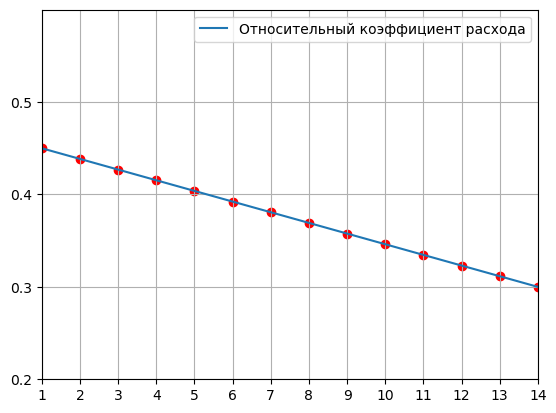

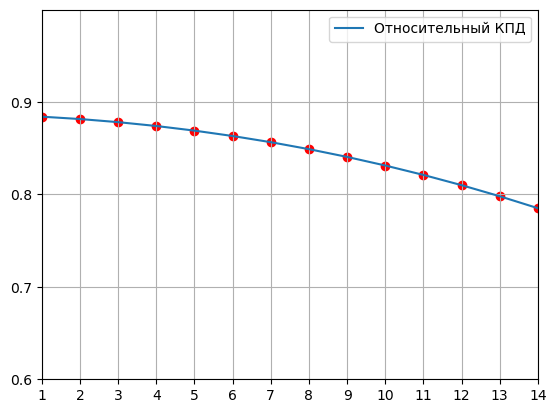

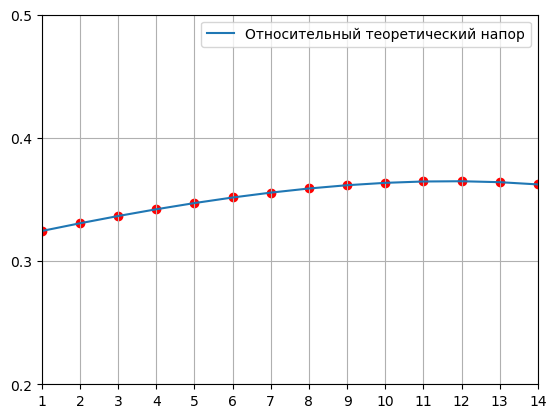

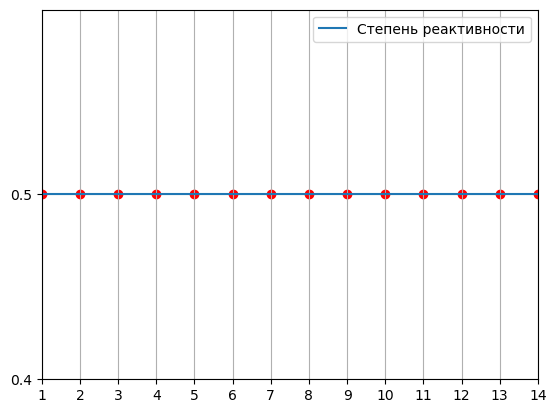

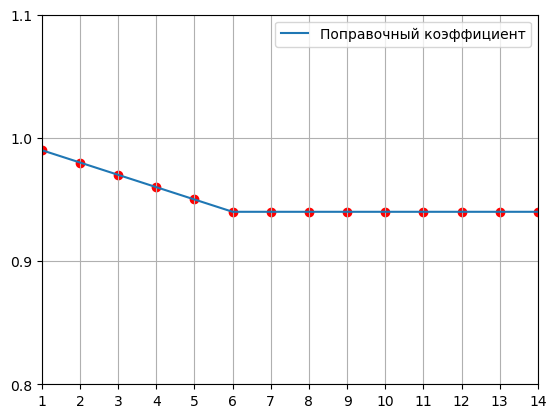

In [204]:
def plot_results(x, y, label_name):
    ylim_min = math.floor(min(y)*10)/10-0.1
    ylim_max = math.ceil(max(y)*10)/10+0.1
    plt.plot(x, y, label=label_name)
    plt.scatter(x, y, color="red")
    plt.xlim(1,max(x))
    plt.ylim(ylim_min, ylim_max)
    plt.xticks(np.arange(1, max(x)+1, 1))
    plt.yticks(np.arange(ylim_min, ylim_max, 0.1))
    plt.grid(True) # Добавление сетки
    plt.legend()
    plt.show()

R_ср1_list = np.linspace(R_ср1, R_ср1, N)  # Создаем массив из N элементов, все равные R_ср1
Kh_i = np.concatenate([
    np.linspace(0.99, 0.94, 6),
    np.full((N-6), 0.94)
])

plot_results(N_list, c_a_i_отн, "Относительный коэффициент расхода")
plot_results(N_list, η_ад_полн_i, "Относительный КПД")
plot_results(N_list, Hт_i_отн, "Относительный теоретический напор")
plot_results(N_list, R_ср1_list, "Степень реактивности")
plot_results(N_list, Kh_i, "Поправочный коэффициент")

In [205]:
# Расчет ВНА
# Коэффициент сохранения полного давления в ВНА
print(f"""
    σ_вх = {σ_вх:.4f} - коэффициент сохранения полного давления в ВНА
    Pa_полн = {Pа_полн:.2f} Па - полное давление на входе в ВНА
    P1_полн = {P1_полн:.2f} Па - полное давление на выходе из ВНА
    c_1u_отн = {c_1u_отн:.4f} - безразмерная окружная составляющая абсолютной скорости на выходе из ВНА""")

# Направление абсолютной скорости на входе в ВНА
α_1_вна = math.radians(90)
α_2_вна = (math.atan(c_а1_отн / c_1u_отн))

print(f"""
    α_1_вна = {math.degrees(α_1_вна):.2f}° - направление абсолютной скорости на входе в ВНА
    α_2_вна = {math.degrees(α_2_вна):.2f}° - направление абсолютной скорости на выходе из ВНА
      """)


    σ_вх = 0.9938 - коэффициент сохранения полного давления в ВНА
    Pa_полн = 101300.00 Па - полное давление на входе в ВНА
    P1_полн = 100674.72 Па - полное давление на выходе из ВНА
    c_1u_отн = 0.2495 - безразмерная окружная составляющая абсолютной скорости на выходе из ВНА

    α_1_вна = 90.00° - направление абсолютной скорости на входе в ВНА
    α_2_вна = 61.00° - направление абсолютной скорости на выходе из ВНА
      


# Создание пустых списков для записи в них значений

In [ ]:
# Коэффициент расхода на выходе из ступени
c_a_i_отн_plus_1 = np.concatenate((c_a_i_отн[1:], [c_a_i_отн[-1]]))

# Давление перед ступенями по длине компрессора
P_полн_i = np.linspace(P1_полн, P2_полн, N)

# Температура перед ступенью по длине компрессора
T1_полн_i = np.linspace(T1_полн, T2_полн, N)

# Окружные скорости по длине компрессора
U_k_i = np.linspace(U_k1, U_k2, N)

# Теоретический напор для i-й ступени:
Hт_i = Hт_i_отн * (U_k_i**2)

# Действительная работа сжатия для i-й ступени:
L_z_i = Kh_i * Hт_i

# Адиабатическая работа сжатия для i-й ступени:
H_ад_i = L_z_i * η_ад_полн_i

# Повышение полной температуры в ступени:
ΔT_полн_i = L_z_i / c_p # с_р в каждой ступени разный т.к. меняется температура

# Полная температура на выходе из ступени:
T3_полн_i = T1_полн_i + ΔT_полн_i
T1_полн_i_plus_1 = T3_полн_i    # Температура на выходе становится температурой на входе в следующую ступень
